<a href="https://colab.research.google.com/github/Jerefilms/DEEP-LEARNING/blob/main/MACHINE%20LEARNING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- VISTA PREVIA DEL DATASET ---
   edad  salario  años_empresa  satisfaccion  horas_extra  renuncia
0    25     1800             1             2           15         1
1    28     2000             2             3           12         1
2    35     3500             5             7            5         0
3    40     4500             8             8            4         0
4    30     2200             2             3           14         1

--- INFORMACIÓN GENERAL ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   edad          20 non-null     int64
 1   salario       20 non-null     int64
 2   años_empresa  20 non-null     int64
 3   satisfaccion  20 non-null     int64
 4   horas_extra   20 non-null     int64
 5   renuncia      20 non-null     int64
dtypes: int64(6)
memory usage: 1.1 KB
None

--- DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (RENUNCIA) ---


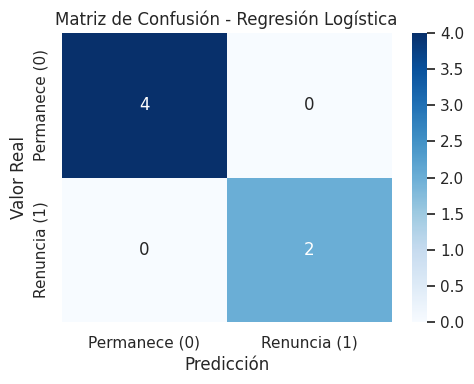

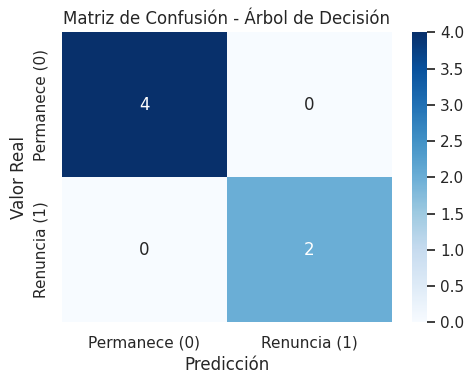

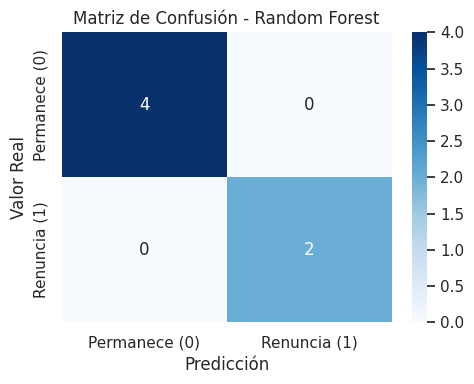

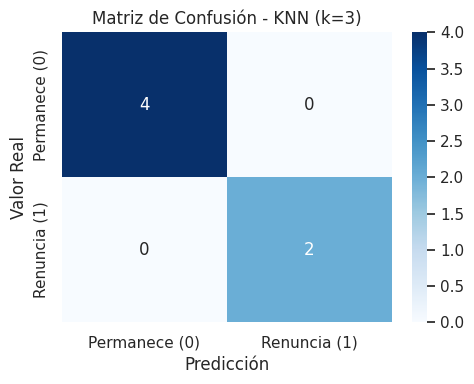

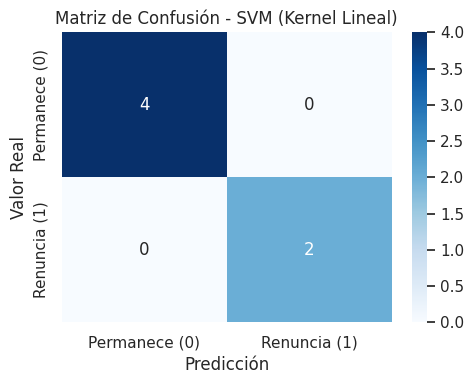

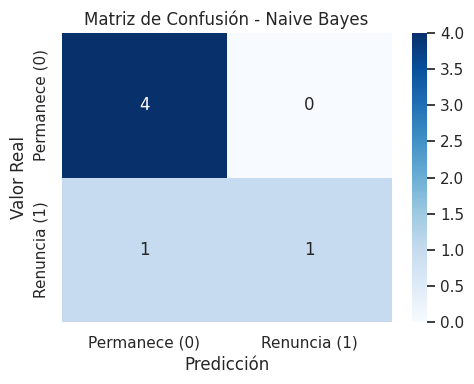


TABLA COMPARATIVA DE RENDIMIENTO DE LOS MODELOS
             Modelo  Accuracy  Precision  Recall  F1-score  CV Promedio
Regresión Logística  1.000000        1.0     1.0  1.000000         1.00
  Árbol de Decisión  1.000000        1.0     1.0  1.000000         1.00
      Random Forest  1.000000        1.0     1.0  1.000000         1.00
          KNN (k=3)  1.000000        1.0     1.0  1.000000         1.00
SVM (Kernel Lineal)  1.000000        1.0     1.0  1.000000         0.95
        Naive Bayes  0.833333        1.0     0.5  0.666667         0.95

********************************************************************************
MEJOR MODELO SEGÚN F1-SCORE: Regresión Logística (F1-Score: 1.00)
********************************************************************************


In [1]:
# ==============================================================================
# PROYECTO: PREDICCIÓN DE ROTACIÓN DE EMPLEADOS (MACHINE LEARNING SUPERVISADO)
# Asignatura: Introducción a Machine Learning
# Librerías principales: Pandas, NumPy, Scikit-Learn, Matplotlib, Seaborn
# DAVID CELIS JEREMICHE
# ==============================================================================

# ------------------------------------------------------------------------------
# 1. IMPORTACIÓN DE LIBRERÍAS
# ------------------------------------------------------------------------------
# Importamos las herramientas de manipulación de datos, cálculo numérico,
# visualización gráfica y modelos de Machine Learning.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Algoritmos de Clasificación de Scikit-Learn
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Estas son las herramientas de evaluación y métricas
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Se establece un estilo gráfico para las visualizaciones
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# ------------------------------------------------------------------------------
# 2. CONSTRUCCIÓN Y EXPLORACIÓN DEL DATASET
# ------------------------------------------------------------------------------
# aca definimos los datos del caso de estudio de Recursos Humanos.
# Variable Objetivo ('renuncia'): 0 = Permanece en la empresa, 1 = Renuncia.
data = {
    "edad": [25, 28, 35, 40, 30, 45, 32, 29, 50, 38, 27, 33, 41, 36, 31, 48, 26, 39, 42, 34],
    "salario": [1800, 2000, 3500, 4500, 2200, 5000, 2800, 2100, 6000, 4000, 1900, 3000, 4700, 3600, 2500, 5500, 1700, 4200, 4800, 3200],
    "años_empresa": [1, 2, 5, 8, 2, 10, 4, 2, 15, 7, 1, 4, 9, 6, 3, 12, 1, 8, 10, 5],
    "satisfaccion": [2, 3, 7, 8, 3, 9, 5, 2, 9, 7, 2, 6, 8, 6, 4, 9, 1, 7, 8, 5],
    "horas_extra": [15, 12, 5, 4, 14, 3, 8, 13, 2, 6, 16, 7, 4, 6, 10, 3, 18, 5, 4, 8],
    "renuncia": [1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0]
}

# Creamos el DataFrame
df = pd.DataFrame(data)

print("--- VISTA PREVIA DEL DATASET ---")
print(df.head())
print("\n--- INFORMACIÓN GENERAL ---")
print(df.info())
print("\n--- DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (RENUNCIA) ---")
print(df["renuncia"].value_counts(normalize=True))

# ------------------------------------------------------------------------------
# 3. PREPARACIÓN DE DATOS (VARIABLES X e Y Y DIVISIÓN TRAIN/TEST)
# ------------------------------------------------------------------------------
# Separamos las variables independientes (X) de la variable objetivo (y)
X = df[["edad", "salario", "años_empresa", "satisfaccion", "horas_extra"]]
y = df["renuncia"]

# División en datos de entrenamiento (70%) y prueba (30%).
# Usamos stratify=y para mantener la proporción de renuncias en ambos subconjuntos.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"\nTamaño conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño conjunto de prueba: {X_test.shape[0]} muestras")

# ------------------------------------------------------------------------------
# 4. ENTRENAMIENTO Y EVALUACIÓN DE MODELOS
# ------------------------------------------------------------------------------
# Inicializamos el diccionario con los 6 algoritmos de clasificación
modelos = {
    "Regresión Logística": LogisticRegression(max_iter=1000, random_state=42),
    "Árbol de Decisión": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN (k=3)": KNeighborsClassifier(n_neighbors=3),
    "SVM (Kernel Lineal)": SVC(kernel="linear", random_state=42),
    "Naive Bayes": GaussianNB()
}

resultados = []

# Iteramos sobre cada modelo para entrenar, predecir y calcular métricas
for nombre, modelo in modelos.items():
    # 1. Entrenamiento con datos de train
    modelo.fit(X_train, y_train)

    # 2. Predicción con datos de test
    y_pred = modelo.predict(X_test)

    # 3. Cálculo de métricas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # 4. Validación Cruzada (CV = 5 folds)
    cv_scores = cross_val_score(modelo, X, y, cv=5, scoring="accuracy")
    cv_mean = cv_scores.mean()

    # Guardamos métricas en la lista
    resultados.append({
        "Modelo": nombre,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "CV Promedio": cv_mean
    })

    # Graficamos la Matriz de Confusión para cada modelo
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Permanece (0)", "Renuncia (1)"], yticklabels=["Permanece (0)", "Renuncia (1)"])
    plt.title(f"Matriz de Confusión - {nombre}")
    plt.xlabel("Predicción")
    plt.ylabel("Valor Real")
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------------------------
# 5. TABLA COMPARATIVA FINAL
# ------------------------------------------------------------------------------
df_resultados = pd.DataFrame(resultados).sort_values(by="F1-score", ascending=False)

print("\n" + "="*80)
print("TABLA COMPARATIVA DE RENDIMIENTO DE LOS MODELOS")
print("="*80)
print(df_resultados.to_string(index=False))

# Identificar el mejor modelo
mejor_modelo = df_resultados.iloc[0]
print("\n" + "*"*80)
print(f"MEJOR MODELO SEGÚN F1-SCORE: {mejor_modelo['Modelo']} (F1-Score: {mejor_modelo['F1-score']:.2f})")
print("*"*80)

In [2]:
data = {
    "edad": [25, 28, 35, 40, 30, 45, 32, 29, 50, 38, 27, 33, 41, 36, 31, 48, 26, 39, 42, 34],
    "salario": [1800, 2000, 3500, 4500, 2200, 5000, 2800, 2100, 6000, 4000, 1900, 3000, 4700, 3600, 2500, 5500, 1700, 4200, 4800, 3200],
    "años_empresa": [1, 2, 5, 8, 2, 10, 4, 2, 15, 7, 1, 4, 9, 6, 3, 12, 1, 8, 10, 5],
    "satisfaccion": [2, 3, 7, 8, 3, 9, 5, 2, 9, 7, 2, 6, 8, 6, 4, 9, 1, 7, 8, 5],
    "horas_extra": [15, 12, 5, 4, 14, 3, 8, 13, 2, 6, 16, 7, 4, 6, 10, 3, 18, 5, 4, 8],
    "renuncia": [1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0]
}

# Creamos el DataFrame
df = pd.DataFrame(data)

print("--- VISTA PREVIA DEL DATASET ---")
print(df.head())
print("\n--- INFORMACIÓN GENERAL ---")
print(df.info())
print("\n--- DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (RENUNCIA) ---")
print(df["renuncia"].value_counts(normalize=True))

--- VISTA PREVIA DEL DATASET ---
   edad  salario  años_empresa  satisfaccion  horas_extra  renuncia
0    25     1800             1             2           15         1
1    28     2000             2             3           12         1
2    35     3500             5             7            5         0
3    40     4500             8             8            4         0
4    30     2200             2             3           14         1

--- INFORMACIÓN GENERAL ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   edad          20 non-null     int64
 1   salario       20 non-null     int64
 2   años_empresa  20 non-null     int64
 3   satisfaccion  20 non-null     int64
 4   horas_extra   20 non-null     int64
 5   renuncia      20 non-null     int64
dtypes: int64(6)
memory usage: 1.1 KB
None

--- DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (RENUNCIA) ---
